# Ambush — a quantitative teardown 🔬
### Pre-registered confluence · HAC inference · Reality Check · a costed, risk-budgeted CFD book

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Rarity defeats costs?: Confirmed](https://img.shields.io/badge/Rarity_defeats_costs%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — same seven beats, every claim now carrying its standard error. The object under test is a *meta-signal*: the count of four pre-existing, individually cost-dead S&P 500 signals firing on the same close.

> ⚠️ **Not investment advice.** SPY split-only daily OHLC + ^VIX raw closes (1993 → as-of 2026-06-01), ^IRX as the per-day cash rate; protocol and thresholds frozen in [`docs/preregistration.md`](../docs/preregistration.md) before the run; sources in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition — so this notebook still reads even if you skim the maths. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))        # the study package (ambush/)
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from ambush import data, signals, strategy
from quantlab.repro import DEFAULT_AS_OF, as_of, fingerprint

spy = as_of(data.spy_frame())
vix = as_of(data.vix_series().to_frame())["vix"]
rf  = as_of(data.rf_series().to_frame())["rf"]
print(f"SPY {spy.index.min().date()} -> {spy.index.max().date()} ({len(spy)} sessions), "
      f"as-of {DEFAULT_AS_OF}")
print("fingerprints:", fingerprint(spy.round(6)), "/", fingerprint(vix.to_frame().round(6)))


SPY 1993-01-29 -> 2026-06-01 (8391 sessions), as-of 2026-06-01


fingerprints: 68198e0c321b / 1d63caa5b039


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| Signal | `REAL` | monotone lift +0.55 → +42.2 bp across K = 0…4; armed K≥3 stream +19.6 bp/day, HAC *t* = **+3.06** (n = 636); RC over the announced family **p = 0.009**; no decay across 2015 (*t*-change +0.17) |
| Tradability | `FRAGILE` | net book survives costs (break-even ~7 bp vs ~1 bp real) but OOS Sharpe **+0.28** < the pre-registered 0.30 bar, CI [-0.23, +0.79] spans 0 |
| Rarity defeats costs? | `CONFIRMED` | spread+financing = 0.40%/yr of a 1.63%/yr gross (~25%), vs >100% for the same signals traded daily (study 19) |

> 💡 **In plain words** — the trap catches real prey, the toll booth can't eat it, but the prey is small.

## 1 · The claim, steelmanned

Liquidity provision after forced selling earns a premium (Nagel 2012; Connors & Alvarez's IBS rule; Lakonishok–Smidt and McConnell–Xu on the month-turn; Whaley's fear gauge). On this bench each expression of that premium is `REAL` gross and `MIRAGE` net — killed by daily turnover, not by the tape (studies 01, 03, 13, 19, 42; study 38 adds that *averaging* signals into a composite forecast also fails). Three testable hypotheses, frozen in advance:

- **H₁** next-day return is monotone increasing in the confluence count;
- **H₂** the K≥3 armed stream clears HAC *t* ≥ 2, surviving a Reality Check over the announced K family;
- **H₃** the K≥3 book — vol-target + 1%/day budget + stop, net of 1 bp one-way + financing — keeps a positive excess Sharpe out-of-sample (≥ 0.30 with CI > 0 for `INVESTABLE`).

## 2 · So what? — what rides on each answer

H₁∧H₂ alone would already be a bench first: a *new* statistically certified signal built from four dead ones — evidence that decay lives in the *trading*, not the *tape*. H₃ decides whether the rarity defence is an actual mechanism or another mirage: at ~15 one-way pairs/yr, a 1 bp toll costs ~3 bp/yr against a ~125 bp/yr gross — if *that* book still dies net, confluence added nothing. The risk overlay is not decoration: it is what makes the result transferable to the smallest real account (a CFD has no contract-size floor; the 1%/day budget is the user's spec, enforced in sizing *and* as a stop).

## 3 · How we'd know — the protocol

1. **Decompose** — the lift table: next-day raw close-to-close SPY return bucketed by today's count; no parameters, no overlay.
2. **Robust inference** — Newey–West *t* on the armed stream; Welch test of the premium *change* across the announced 2015 split; circular-block-bootstrap CI on the book's Sharpe; White (2000) Reality Check on the stationary bootstrap across K∈{1,2,3,4} — the whole family we looked at, declared before looking.
3. **Critique** — one execution lag exactly (signals at close *t* earn *t+1*; the TOM leg is calendar-known and marks *tomorrow's* membership before receiving that same lag); split-only data choice stated; VIX forward-filled across holiday gaps, never backfilled.
4. **Alpha vs beta** — the book is raced **excess-of-cash vs excess-of-cash** against SPY B&H (a 7.6%-in-market book on raw Sharpe vs an always-long benchmark would just measure who held more T-bills — bench rule).
5. **Execution & capacity** — cost sweep to break-even, full and OOS; financing charged per held night; stop exits pay the spread too.
6. **Controls** — planted-premium tape must light up, seeded random walk must stay dark (`tests/test_synth_controls.py`, run in CI).

> 💡 **In plain words** — we wrote the rules of the game, the referee, and the losing conditions on paper first, then played once.

## 4 · The teardown

### 4.1 The lift is monotone (H₁)

,next_bps,n,share
count,,,
0,0.550,3392,0.400
1,1.910,2772,0.330
2,9.210,1590,0.190
3,17.180,574,0.070
4,42.190,62,0.010


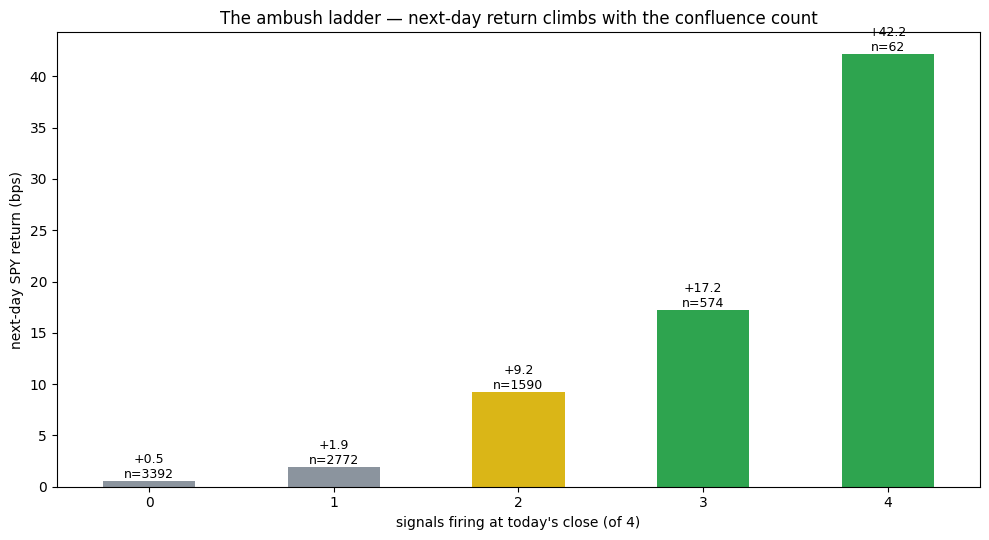

In [2]:
lift = strategy.lift_table(spy, vix)
display(lift.round(2))

ax = lift["next_bps"].plot.bar(color=["#8b949e"]*2 + ["#dab617"] + ["#2ea44f"]*2, rot=0)
ax.set_xlabel("signals firing at today's close (of 4)")
ax.set_ylabel("next-day SPY return (bps)")
ax.set_title("The ambush ladder — next-day return climbs with the confluence count")
for i, (v, n) in enumerate(zip(lift["next_bps"], lift["n"])):
    ax.annotate(f"{v:+.1f}\nn={n}", (i, v), ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()


### 4.2 …and statistically real under HAC errors (H₂, first leg)

In [3]:
from quantlab.analytics import mean_tstat_hac
for k in (2, 3, 4):
    t = mean_tstat_hac(strategy.armed_stream(spy, vix, k=k))
    print(f"armed K>={k}: {t['mean_bps']:+5.1f} bp/day | HAC t = {t['tstat']:+.2f} | n = {t['n']}")


armed K>=2: +12.2 bp/day | HAC t = +4.66 | n = 2226
armed K>=3: +19.6 bp/day | HAC t = +3.06 | n = 636
armed K>=4: +42.2 bp/day | HAC t = +2.43 | n = 62


> 💡 **In plain words** — even letting the noisy days lean on each other (Newey–West), the ≥3-signal premium is more than three standard errors from zero.

### 4.3 No decay across the pre-registered split — unlike every ingredient

In [4]:
dec = strategy.premium_change(spy, vix, k=3, split="2015")
print(f"armed-day premium over the rest: {dec['premium_pre_bp']:+.1f} bp/day before 2015 "
      f"(Welch t {dec['welch_t_pre']:+.2f}) -> {dec['premium_post_bp']:+.1f} bp/day since "
      f"(t {dec['welch_t_post']:+.2f})")
print(f"test of the *difference*: t_change = {dec['t_change']:+.2f}  ->  no detectable decay")


armed-day premium over the rest: +17.6 bp/day before 2015 (Welch t +2.07) -> +15.3 bp/day since (t +1.32)
test of the *difference*: t_change = +0.17  ->  no detectable decay


Each ingredient's own study found gross decay (19: Sharpe halved; 42: premium −94% post-2008; 67: gone entirely). The *confluence* premium is statistically flat across 2015 — consistent with the crowding story: everyone arbitrages the everyday expression of liquidity provision; the 7%-of-days tail keeps paying.

### 4.4 The selection correction (H₂, second leg)

In [5]:
from quantlab import bayes
rc = bayes.reality_check(strategy.variant_panel(spy, vix, rf), n_boot=2000, seed=0)
print(f"family K in {{1,2,3,4}} (announced in the pre-registration, all of it):")
print(f"best net Sharpe {rc['observed_max_sharpe']:+.2f} -> Reality-Check p = "
      f"{rc['reality_check_pvalue']:.3f} (stationary bootstrap, {rc['n_boot']} draws)")


family K in {1,2,3,4} (announced in the pre-registration, all of it):
best net Sharpe +0.42 -> Reality-Check p = 0.009 (stationary bootstrap, 2000 draws)


> 💡 **In plain words** — 'the best of four variants' is significant by construction unless you punish yourself for having looked at four; after the punishment, p ≈ 0.01.

### 4.5 The book (H₃): overlay, costs, IS/OOS

,sharpe,excess/yr,time in mkt,trades/yr,OOS sharpe
book,,,,,
K>=1,0.351,0.024,0.594,52.833,0.350
K>=2,0.408,0.020,0.265,43.762,0.405
K>=3,0.424,0.012,0.076,15.078,0.278
K>=4,0.284,0.002,0.007,1.772,0.006
SPY B&H (excess),0.420,0.078,1.000,0.000,0.622


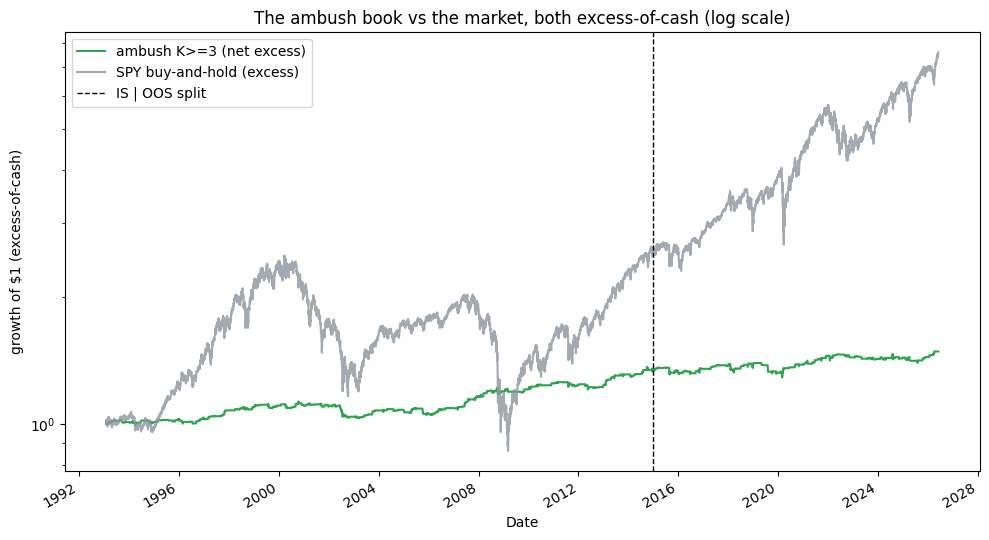

In [6]:
rows, curves = [], {}
for k in (1, 2, 3, 4):
    led = strategy.book(spy, vix, rf, k=k)
    s  = strategy.summary(led["net_excess"], led)
    so = strategy.summary(led["net_excess"]["2015":], led["2015":])
    rows.append({"book": f"K>={k}", "sharpe": s["sharpe"], "excess/yr": s["ann_excess"],
                 "time in mkt": s["time_in_market"], "trades/yr": s["trades_per_year"],
                 "OOS sharpe": so["sharpe"]})
    curves[f"K>={k}"] = (1 + led["net_excess"]).cumprod()
bh = strategy.bh_excess(spy, rf)
rows.append({"book": "SPY B&H (excess)", "sharpe": strategy.summary(bh)["sharpe"],
             "excess/yr": strategy.summary(bh)["ann_excess"], "time in mkt": 1.0,
             "trades/yr": 0, "OOS sharpe": strategy.summary(bh["2015":])["sharpe"]})
display(pd.DataFrame(rows).set_index("book").round(3))

ax = curves["K>=3"].plot(label="ambush K>=3 (net excess)", color="#2ea44f")
(1 + bh).cumprod().plot(ax=ax, label="SPY buy-and-hold (excess)", color="#8b949e", alpha=0.8)
ax.axvline(pd.Timestamp("2015-01-01"), ls="--", c="k", lw=1, label="IS | OOS split")
ax.set_yscale("log"); ax.legend(); ax.set_ylabel("growth of $1 (excess-of-cash)")
ax.set_title("The ambush book vs the market, both excess-of-cash (log scale)")
plt.tight_layout(); plt.show()


Full-sample the K≥3 book matches the market's excess Sharpe (+0.42 vs +0.42) while exposed 8% of the time; OOS it earns +0.28 against the market's great decade (+0.62). K≥4 is the cautionary row: +0.01 OOS on ~2 trades/yr — 62 events in 33 years is a sample, not a strategy.

### 4.6 Cost anatomy and the moat

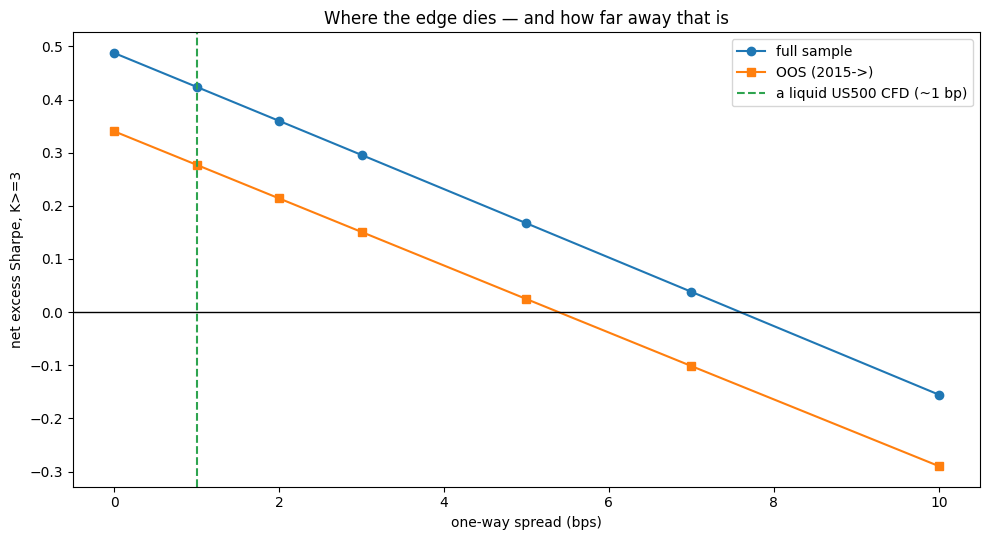

In [7]:
sw_full = strategy.cost_sweep(spy, vix, rf)
sw_oos  = strategy.cost_sweep(spy["2014-10":], vix, rf)   # 3-month warm-up for the vol estimator
ax = sw_full["net_sharpe"].plot(marker="o", label="full sample")
sw_oos["net_sharpe"].plot(ax=ax, marker="s", label="OOS (2015->)")
ax.axhline(0, c="k", lw=1); ax.axvline(1.0, ls="--", c="#2ea44f", label="a liquid US500 CFD (~1 bp)")
ax.set_xlabel("one-way spread (bps)"); ax.set_ylabel("net excess Sharpe, K>=3")
ax.set_title("Where the edge dies — and how far away that is")
ax.legend(); plt.tight_layout(); plt.show()


### 4.7 The risk overlay, audited

exposure when armed: median 0.52x, max 1.65x
stop fires 2.1x/yr | worst single day -2.62% | max drawdown -8.9%


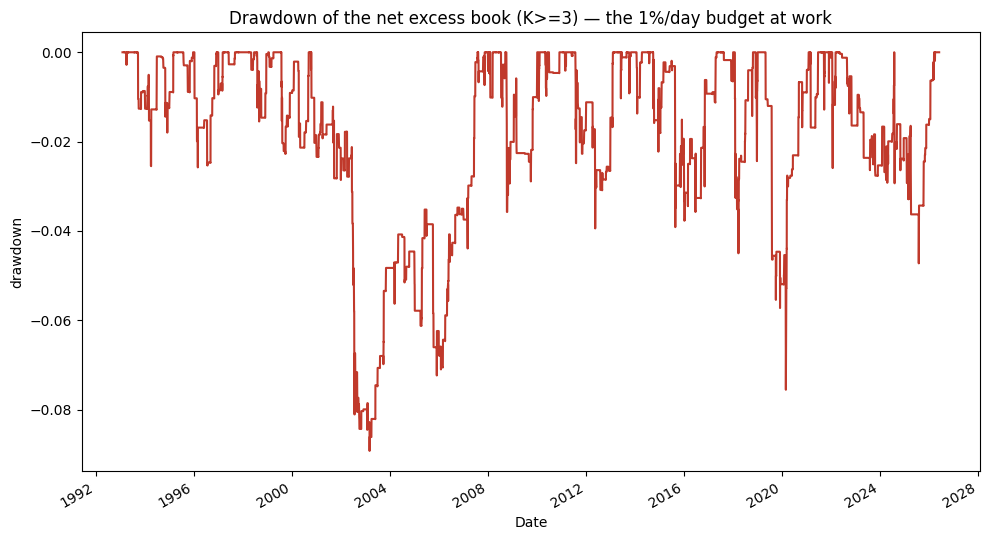

In [8]:
led = strategy.book(spy, vix, rf, k=3)
held = led[led["pos"] > 0]
eq = (1 + led["net_excess"]).cumprod()
dd = eq / eq.cummax() - 1
print(f"exposure when armed: median {held['pos'].median():.2f}x, max {held['pos'].max():.2f}x")
print(f"stop fires {led['stopped'].sum() / (len(led)/252):.1f}x/yr | "
      f"worst single day {led['net_excess'].min():+.2%} | max drawdown {dd.min():.1%}")
ax = dd.plot(color="#c0392b"); ax.set_title("Drawdown of the net excess book (K>=3) — the 1%/day budget at work")
ax.set_ylabel("drawdown"); plt.tight_layout(); plt.show()


## 5 · The verdict

- **H₁ monotone:** confirmed, +0.55 → +1.91 → +9.21 → +17.18 → +42.19 bp.
- **H₂ real:** HAC *t* = +3.06 (K≥3), RC p = 0.009, decay *t*-change +0.17 ⇒ **Signal `REAL`**.
- **H₃ tradable:** full-sample net Sharpe +0.42 (CI [+0.10, +0.73]), OOS +0.28 (CI [-0.23, +0.79]) — positive, surviving costs, **but** below the frozen 0.30 bar with a CI through zero ⇒ **Tradability `FRAGILE`**, by the letter of the pre-registration.
- **Mechanism:** costs+financing take 25% of gross at ~15 trades/yr ⇒ **Rarity defeats costs `CONFIRMED`** — the bench's first deliberate, working cost defence.

## 6 · Could you trade it?

**Venue** — a US500 CFD (no size floor) or MES futures (cheaper financing, ~$5 notional floor per 0.25 pt tick is irrelevant at this size). **Costs** — the moat is real: break-even ~7 bp one-way full-sample (~5 bp OOS) against ~0.5–1 bp on a tight US500 quote; CFD weekend financing and close-auction spread widening shave it but don't close it. **Risk** — median exposure 0.52×, stop 2.1×/yr, max excess drawdown -8.9%, worst day -2.62% (gap through the stop — the 1% budget binds at the stop, not through a gap; an overnight index gap >2× the stop distance is rare but real). **Capacity** — effectively unlimited at retail size; the premium is ~20 bp on ~$0.5×NAV fifteen times a year. **The candid line** — +1.23%/yr excess is a *sleeve*, not a strategy: its value is that it is uncorrelated by construction with being long (flat 92% of days) and costs nothing to hold. Anyone selling this as a get-rich machine is selling the lift table without the time-in-market column.

## 7 · Going further

- **Overnight-only exit** (close→open on armed days, study 01's leg): halves financing and the gap-risk window; needs the open auction's effective spread.
- **Sizing by count** — w ∝ (K−2) instead of flat: the lift table says K=4 is worth 2.5× K=3; 62 events can't certify it (that's *why* it wasn't pre-registered).
- **Cross-market replication** — the same four definitions run unchanged on QQQ/EWJ/EWG tapes already in `_cache/`; a confluence premium that exists *only* on SPY would be a red flag worth publishing either way.
- **PR welcome** — `ambush/` is ~300 lines; every threshold is a named constant; `tests/` pins the accounting (one lag, costs both legs, stop, budget) so a fork can't silently cheat.

*Numbers in prose: [`docs/results.md`](../docs/results.md) (fingerprints `68198e0c321b` / `1d63caa5b039`, as-of 2026-06-01). Reproduce: `python examples/verify.py`.*